# Comparison of paths and Gisaid statistics


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

import seaborn as sns
import os, sys
main_path = '../'

sys.path.append(main_path + 'PGM/source/')
sys.path.append(main_path + 'PGM/utilities/')
import utilities, Proteins_utils, sequence_logo, plots_utils, RBM_utils

sys.path.append(main_path + 'path/')
#importlib

from importlib import reload, import_module

from path_nucleotide import *


from global_variables import *
from utils_evaluate_seq import *





e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loaded 29 KD vectors


# Comparison with aa paths

In [2]:


PROT_INIT_AA = Proteins_utils.load_FASTA("../covid/exp_data/wt_omicron.fasta")[0]
PROT_INIT_AA = PROT_INIT_AA[BEGIN:-END]

In [3]:
beta_w=1
beta_phi=1

one_hot_wt=one_hot_encode_concat(PROT_INIT_AA)
indexes=np.where(one_hot_wt==1)[0]
indexes

array([  15,   37,   59,   60,   98,  111,  134,  148,  174,  187,  215,
        231,  241,  277,  280,  302,  339,  355,  377,  389,  419,  431,
        455,  460,  495,  504,  535,  556,  564,  588,  601,  639,  645,
        677,  695,  712,  736,  748,  769,  791,  802,  829,  841,  864,
        896,  911,  937,  959,  960,  982, 1015, 1024, 1057, 1067, 1094,
       1105, 1122, 1143, 1177, 1194, 1213, 1227, 1240, 1272, 1285, 1313,
       1336, 1345, 1368, 1387, 1400, 1422, 1459, 1471, 1499, 1508, 1529,
       1552, 1562, 1582, 1604, 1636, 1645, 1661, 1697, 1707, 1720, 1758,
       1771, 1795, 1811, 1831, 1849, 1862, 1895, 1908, 1937, 1945, 1965,
       1991, 2019, 2031, 2059, 2069, 2099, 2114, 2129, 2144, 2174, 2188,
       2215, 2231, 2249, 2268, 2292, 2304, 2323, 2354, 2362, 2387, 2415,
       2436, 2443, 2467, 2499, 2513, 2520, 2545, 2575, 2596, 2612, 2621,
       2651, 2665, 2697, 2703, 2725, 2744, 2771, 2781, 2819, 2824, 2852,
       2869, 2893, 2915, 2939, 2945, 2964, 2993, 30

In [4]:
from typing import Callable, List, Sequence


def read_fasta_nt(path: str) -> List[np.ndarray]:
    """Read a FASTA file of nucleotide sequences → list of int‑encoded nt arrays.

    Assumes DNA alphabet A/C/G/T (case‑insensitive). Ignores empty lines.
    """
    sequences: List[str] = []
    with open(path, "r") as fh:
        seq = ""
        for line in fh:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if seq:
                    sequences.append(seq.upper())
                    seq = ""
            else:
                seq += line.upper()
        if seq:
            sequences.append(seq.upper())

    nt_arrays: List[np.ndarray] = []
    for s in sequences:
        if any(ch not in CODE_NT for ch in s):
            raise ValueError(f"Non‑ACGT character found in sequence {s[:30]}…")
        if len(s) % 3 != 0:
            raise ValueError("Sequence length not multiple of 3: " + s[:30])
        nt_arrays.append(np.asarray([CODE_NT.index(b) for b in s], dtype=np.int16))
    return nt_arrays


def fasta_to_aa_idx_arrays(path: str) -> List[np.ndarray]:
    """Convenience wrapper: FASTA of nts → list of AA‑index arrays."""
    nt_arrays = read_fasta_nt(path)
    return [translate_idx(nt) for nt in nt_arrays]

## Correlation gisaid

In [ ]:
AA = list('ACDEFGHIKLMNPQRSTVWY')

# Entropy function
def site_entropy(seq_list):
    """Compute entropy at each site across sequences."""
    L = len(seq_list[0])
    A = len(AA)
    aa_to_index = {aa: i for i, aa in enumerate(AA)}
    count_matrix = np.zeros((L, A))

    for seq in seq_list:
        for i, aa in enumerate(seq):
            if aa in aa_to_index:
                count_matrix[i, aa_to_index[aa]] += 1
            else:# already encoded
                count_matrix[i, aa] += 1


    probs = count_matrix / count_matrix.sum(axis=1, keepdims=True)
    epsilon = 1e-12
    ent = -np.sum(probs * np.log(probs + epsilon), axis=1)
    return ent
rbd_unique=pd.read_csv('../covid/gisaid/rbd_df.csv')
seqs=rbd_unique['sequence'].tolist()
entropy_unique = site_entropy(seqs)
entropy_unique.shape


(178,)

In [ ]:
import pandas as pd
import numpy as np
import os

# --- CONFIGURATION ---
GISAID_PATH = "../covid/gisaid/all_mutation_summary.csv"
SITE_OFFSET = 349  # The starting residue number (index 0 = site 349)
# ---------------------

# 1. Load and Preprocess GISAID Data
# -------------------------------------------------------
print("Loading GISAID summary...")
df_base = pd.read_csv(GISAID_PATH)

# Filter: seen at least 100 times (Frequency >= 100)
# 'first_seen_100' is assumed to be NaN if the mutation count is < 100
df_seen = df_base.dropna(subset=["first_seen_100"]).copy()

# Extract site number from mutation string (e.g., "A349C" -> 349)
def extract_site(mut_str):
    try:
        return int(mut_str[1:-1])
    except:
        return -1

df_seen['site_num'] = df_seen['mutation'].apply(extract_site)

# Count unique amino acid variations observed per site
# (e.g., if site 484 has E484K, E484Q, E484A -> count is 3)
observed_counts_map = df_seen.groupby('site_num')['mutation'].nunique().to_dict()
# create array of size 178 having observed [349+i] as item
# Define the size and offset
SEQUENCE_LENGTH = 178
SITE_OFFSET = 349

# Create the array using a list comprehension for efficiency
# We look up site (349 + i) in the map, defaulting to 0 if the site has no mutations
observed = np.array([observed_counts_map.get(SITE_OFFSET + i, 0) for i in range(SEQUENCE_LENGTH)])

print(f"Created 'observed' array of shape: {observed.shape}")
print(f"First 10 values: {observed[:10]}")

Loading GISAID summary...
Created 'observed' array of shape: (178,)
First 10 values: [1 0 0 2 0 5 0 5 1 1]


In [8]:
def get_mcmc_entropy(dir,step,aa=True): 
    paths_nb=100
    print("beta_w", beta_w)
    last_seq_list = [] 
    for path_no in range(paths_nb):
        fasta_file = os.path.join(dir, f"output_{path_no}.fasta")
        if not os.path.exists(fasta_file):
            print('not found')
            continue
        if aa:
            sequences = Proteins_utils.load_FASTA(fasta_file, drop_duplicates=False)
        else:
            sequences=fasta_to_aa_idx_arrays(fasta_file)
        last_seq = sequences[step]  # Get the step sequence
        last_seq_list.append(last_seq)  # Append to the list

    last_seq_list=np.array(last_seq_list)
    s=site_entropy(last_seq_list)
  
    return s

def get_mcmc_path_entropy(dir,aa=True):
    s_list=[]
    for step in range(21):
        s_list.append(get_mcmc_entropy(dir, step, aa))
    s_list=np.array(s_list)
    return s_list



In [17]:
beta_w=5
dir_mcmc = f"../covid/paths/test_covid_T20_beta_ab_{beta_w}/"
entropy_mcmc=get_mcmc_path_entropy(dir_mcmc)
dir_mcmc_nt = f"../covid/paths_nt/test_nt_covid_T_20_beta_ab_{beta_w}/"
entropy_mcmc_nt=get_mcmc_path_entropy(dir_mcmc_nt, aa=False)
dir_mcmc_nt=get_mcmc_path_entropy(dir_mcmc)


beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5
beta_w 5


In [35]:
path_proba = '../mean_field_theory/results_scripts/covid_D_20/mean_f_free_ab_beta_ab_5_D_1.npy'
probas = np.load(path_proba)  # shape: (amino_acid, step, site)
#round to cloestes 10^4
probas = np.round(probas, 6)  # Round to 4 decimal places
entropy_mf=[]
epsilon = 1e-12
# probas = np.clip(probas, 0.0001, 1.0)

for step in range (probas.shape[1]):
    entropy_mf.append(-np.sum(probas[:,step,:] * np.log(probas[:,step,:] + epsilon), axis=0) )
entropy_mf=np.array(entropy_mf)

print(entropy_mf.shape)  # (n_steps, n_sites)

(21, 178)


In [36]:
probas[:,0,:]
#make sure entropy per site is constant
for i in range(probas.shape[2]):
    print(f"Site {i}: {np.sum(probas[:,0,i])}")  # should be close to 1.0
    print(f"Entropy at site {i}: {entropy_mf[:,i].mean()}")  # should be constant across steps

Site 0: 1.0
Entropy at site 0: 1.947490609509675e-05
Site 1: 1.0
Entropy at site 1: 1.4745104341886358e-05
Site 2: 1.0
Entropy at site 2: 0.00022674695265567738
Site 3: 1.0
Entropy at site 3: 0.002348930790894841
Site 4: 1.0
Entropy at site 4: 4.183864050412024e-05
Site 5: 1.0
Entropy at site 5: 0.0014733096391332076
Site 6: 1.0
Entropy at site 6: 0.00029778762684903
Site 7: 1.0
Entropy at site 7: 0.16265398136122752
Site 8: 1.0
Entropy at site 8: 0.21249847718822418
Site 9: 1.0
Entropy at site 9: 0.00019775489306607125
Site 10: 1.0
Entropy at site 10: 0.0004993933211426714
Site 11: 1.0
Entropy at site 11: 0.00021914469193280866
Site 12: 1.0
Entropy at site 12: 6.155684245420177e-05
Site 13: 1.0
Entropy at site 13: 0.0032942614579984384
Site 14: 1.0
Entropy at site 14: 0.1725764076428708
Site 15: 1.0
Entropy at site 15: 0.00011939891001272136
Site 16: 1.0
Entropy at site 16: 0.12274530876710944
Site 17: 1.0
Entropy at site 17: 0.001620669578409487
Site 18: 1.0
Entropy at site 18: 0.007

AUC sizes: AA=21, NT=21, MF=21


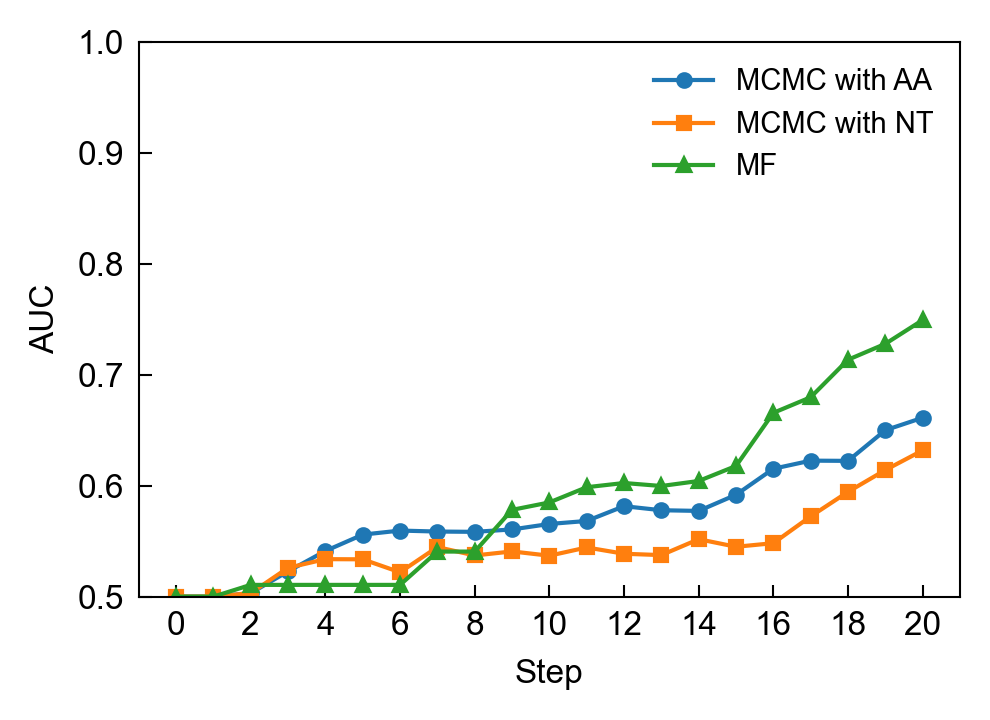

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute AUC per step
auc_aa = []
auc_nt = []
auc_mf = []
steps = range(21)

for step in steps:
    x = entropy_mcmc[step]
    xbis = entropy_mcmc_nt[step]

    x_ter = entropy_mf[step]

    # y = (entropy_unique > np.log(2)).astype(int)
    y= (observed >= 2).astype(int)

    fpr, tpr, _ = roc_curve(y, x)
    auc_aa.append(auc(fpr, tpr))

    fprbis, tprbis, _ = roc_curve(y, xbis)
    auc_nt.append(auc(fprbis, tprbis))

    fpr_mf, tpr_mf, _ = roc_curve(y, x_ter)
    auc_mf.append(auc(fpr_mf, tpr_mf))
#print size of auc_aa, auc_nt, auc_mf
print(f"AUC sizes: AA={len(auc_aa)}, NT={len(auc_nt)}, MF={len(auc_mf)}")


# --- Plotting with PRL style ---
plt.figure(figsize=(3.4, 2.5))  # PRL 1-column figure size (in inches)
plt.plot(steps, auc_aa, marker='o', markersize=3, linewidth=1, label="MCMC with AA")
plt.plot(steps, auc_nt, marker='s', markersize=3, linewidth=1, label="MCMC with NT")
plt.plot(steps, auc_mf, marker='^', markersize=3, linewidth=1, label="MF")

plt.xlabel("Step", fontsize=8)
plt.ylabel("AUC", fontsize=8)
plt.xticks(np.arange(min(steps), max(steps)+1, 2), fontsize=8)
plt.yticks(fontsize=8)
plt.ylim(0.5, 1.0)

# No box around legend, small font
plt.legend(fontsize=7, frameon=False, loc="best")

# Thinner spines and ticks inside
ax = plt.gca()
ax.tick_params(axis='both', which='both', direction='in', length=3, width=0.5)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()


#plot the auc for last step


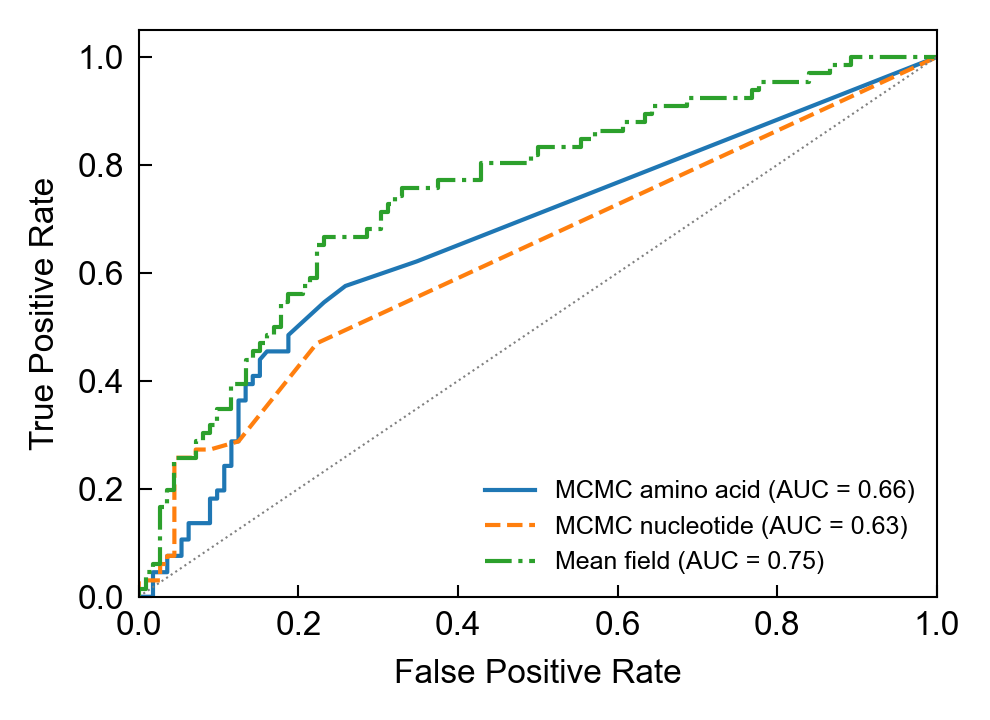

In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# --- Data Preparation (Last Step) ---
# Assuming entropy_unique, entropy_mcmc, etc. are available from your previous context
last_step_idx = -1

# Re-define ground truth (y) and scores (x) for the last step
# y_true = (entropy_unique > np.log(2)).astype(int)
y_true= (observed >= 2).astype(int)

scores_aa = entropy_mcmc[last_step_idx]
scores_nt = entropy_mcmc_nt[last_step_idx]
scores_mf = entropy_mf[last_step_idx]

# --- Compute Curves ---
fpr_aa, tpr_aa, _ = roc_curve(y_true, scores_aa)
roc_auc_aa = auc(fpr_aa, tpr_aa)

fpr_nt, tpr_nt, _ = roc_curve(y_true, scores_nt)
roc_auc_nt = auc(fpr_nt, tpr_nt)

fpr_mf, tpr_mf, _ = roc_curve(y_true, scores_mf)
roc_auc_mf = auc(fpr_mf, tpr_mf)

# --- Plotting ---
plt.figure(figsize=(3.4, 2.5))

# Plot ROC curves
plt.plot(fpr_aa, tpr_aa, lw=1, label=f'MCMC amino acid (AUC = {roc_auc_aa:.2f})')
plt.plot(fpr_nt, tpr_nt, lw=1, ls='--', label=f'MCMC nucleotide (AUC = {roc_auc_nt:.2f})')
plt.plot(fpr_mf, tpr_mf, lw=1, ls='-.', label=f'Mean field (AUC = {roc_auc_mf:.2f})')

# Plot Diagonal (Random Guess)
plt.plot([0, 1], [0, 1], color='gray', lw=0.5, linestyle=':')

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=8)
plt.ylabel('True Positive Rate', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# Legend
plt.legend(loc="lower right", fontsize=6, frameon=False)

# Style adjustments (Thin spines, inward ticks)
ax = plt.gca()
ax.tick_params(axis='both', which='both', direction='in', length=3, width=0.5)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()